In [43]:
# Import pandas for data manipulation
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

# Import KMeans clustering algorithm
from sklearn.cluster import KMeans

# Import LabelEncoder, OneHotEncoder, and StandardScaler for preprocessing
from sklearn.preprocessing import LabelEncoder,  StandardScaler

# Import silhouette_score to evaluate clustering performance
from sklearn.metrics import silhouette_score
import warnings

# Ignore warning messages
warnings.filterwarnings("ignore")

In [44]:
df=pd.read_csv('Dataset/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [45]:
sns.boxplot(df[['Age','Annual Income (k$)','Spending Score (1-100)']])
plt.close()


In [46]:
# Create a LabelEncoder object
le = LabelEncoder()

In [47]:
df['Gender_Id']=le.fit_transform(df['Gender'])


In [48]:
df=df.drop(columns='Gender')


In [49]:
#df['Gender']=le.inverse_transform(df['Gender_Id'])

In [50]:
df.columns

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_Id'],
      dtype='object')

In [51]:

# Create OneHotEncoder object
#encoder = OneHotEncoder(drop='first', sparse_output=False)

# Apply one-hot encoding to the Gender column
#gender_encoder = encoder.fit_transform(df[['Gender']])

# Convert encoded data into a DataFrame
#gender_df = pd.DataFrame(
#    gender_encoder,
 #   columns=encoder.get_feature_names_out(['Gender'])
#)

# Display the DataFrame
#gender_df


In [52]:
# Join the encoded Gender columns to the original DataFrame
#df = df.join(gender_df)

# Display the updated DataFrame
#df

In [53]:
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Id
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [54]:
X=df[[ 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_Id']]

In [55]:
scaler= StandardScaler()

In [56]:
X_scale=scaler.fit_transform(X)

In [57]:
k_range=range(2,21)
error_rate=[]

In [58]:
for i in k_range:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit_predict(X_scale)
    error_rate.append(kmeans.inertia_)
    
    


Text(0.5, 1.0, 'Elbow Method:kmeans(cluster segmentation')

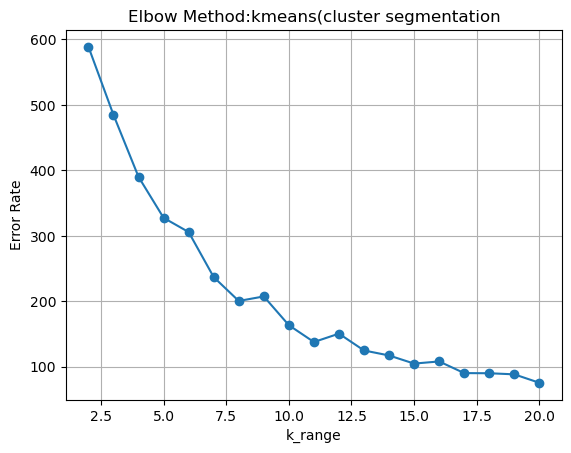

In [59]:
plt.plot(k_range,error_rate,marker='o')
plt.grid()
plt.xlabel("k_range")
plt.ylabel("Error Rate")
plt.title("Elbow Method:kmeans(cluster segmentation")


In [60]:
# Set the number of clusters
k = 5

# Create a KMeans model with 5 clusters
model = KMeans(n_clusters=5)

# Fit the model to the scaled data and predict the cluster labels
cluster=model.fit_predict(X_scale)


In [61]:
df['cluster']=cluster
df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Id,cluster
0,1,19,15,39,1,3
1,2,21,15,81,1,3
2,3,20,16,6,0,4
3,4,23,16,77,0,0
4,5,31,17,40,0,4
...,...,...,...,...,...,...
195,196,35,120,79,0,0
196,197,45,126,28,0,2
197,198,32,126,74,1,3
198,199,32,137,18,1,2


In [62]:
'''
silhouette_score
-------------
-1:All clusters forms in one cloud formation(wrong cluster)

near o and below 1:some clusters overlap eachother(considerable)

1+:all cluster are far distance from other cluster(perfect cluster formation)

'''

'\nsilhouette_score\n-------------\n-1:All clusters forms in one cloud formation(wrong cluster)\n\nnear o and below 1:some clusters overlap eachother(considerable)\n\n1+:all cluster are far distance from other cluster(perfect cluster formation)\n\n'

In [63]:
sc=silhouette_score(X_scale,cluster)
print(f'cluster silhouette_score:{sc} ')

cluster silhouette_score:0.3169033909887276 


<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

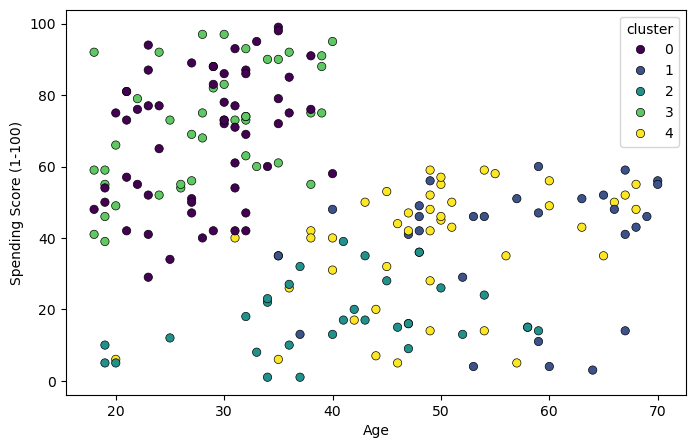

In [64]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='Age', y='Spending Score (1-100)',hue='cluster',palette='viridis',edgecolor='black')


In [65]:
#pair plot
pair_plot=df

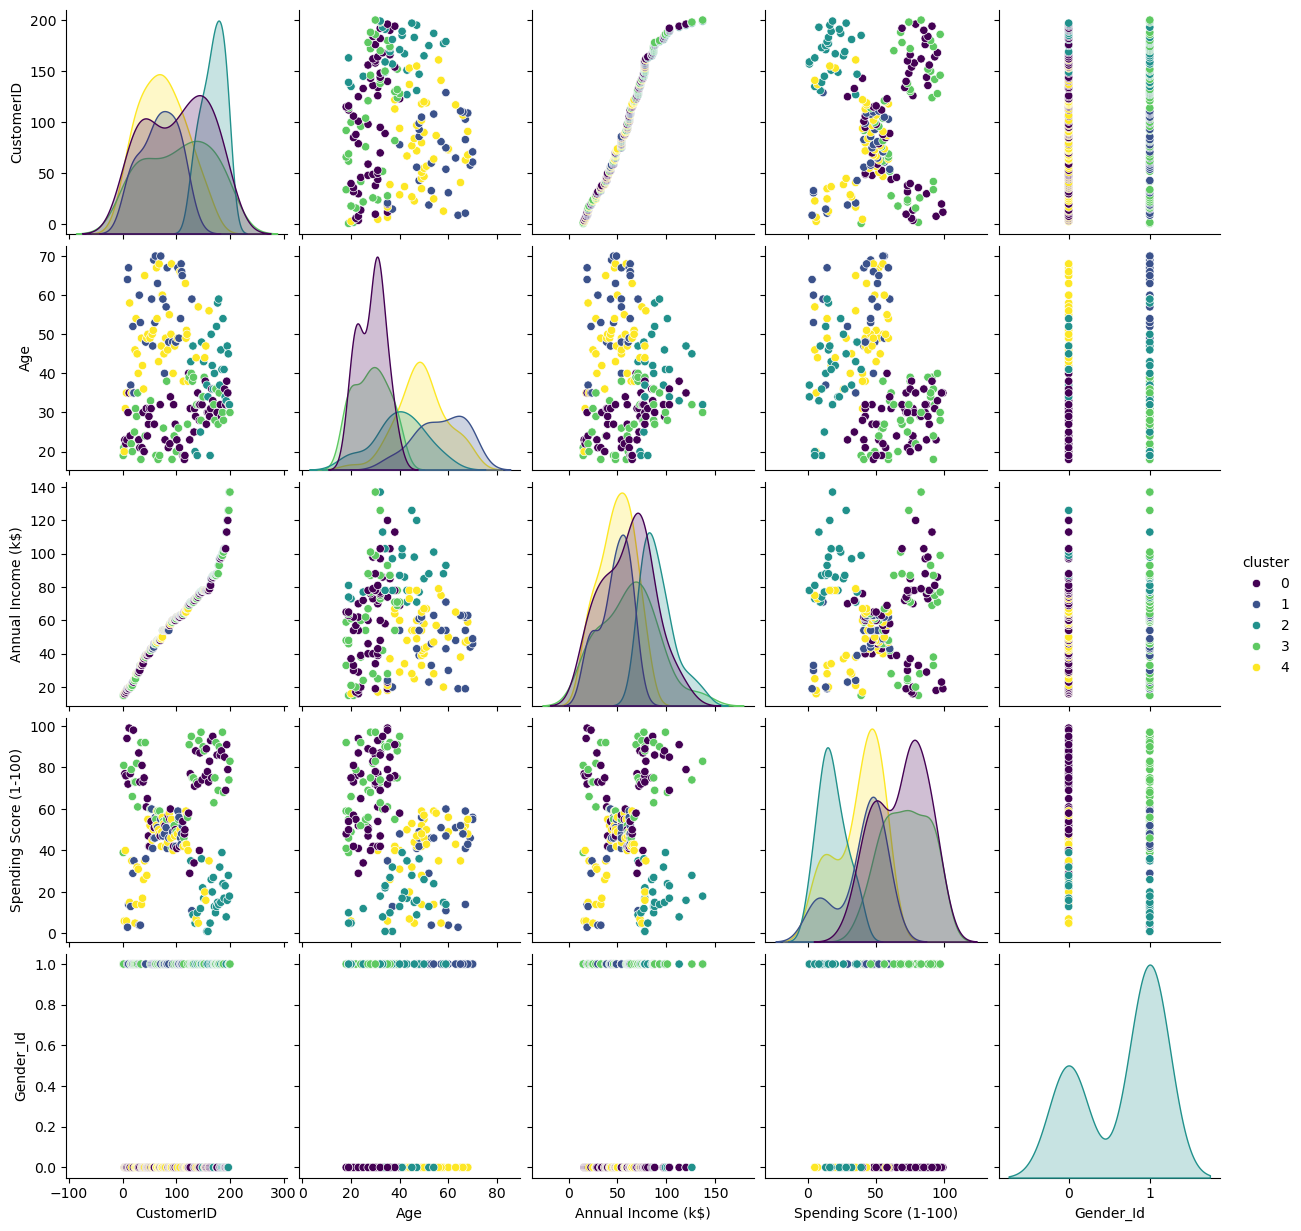

In [66]:
sns.pairplot(
    data=df,
    hue='cluster',
    palette='viridis'
)

plt.show()

In [67]:
'''
#pc1 pc2 pc3 pc4
#high low low loww 
eigenvector->direction (left to right)

eigenvalue->(top to bottom)
'''

'\n#pc1 pc2 pc3 pc4\n#high low low loww \neigenvector->direction (left to right)\n\neigenvalue->(top to bottom)\n'

In [68]:

from sklearn.decomposition import PCA

In [69]:
 features=['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_Id']

In [70]:
pca = PCA(n_components=len(features))

In [71]:
X_pca=pca.fit_transform(X_scale) #covariance

In [72]:
#covariance->eigenvector and eigenscale
# Covariance -> Eigenvectors (Loadings)

#covariance->eigenvector and eigenscale
loadings=pd.DataFrame(
    
    pca.components_,
    index=features,
    columns = [f'PC{i+1}' for i in range(len(features))]
)


In [73]:
loadings

,PC1,PC2,PC3,PC4
Age,0.687900,-0.006082,-0.686920,0.234302
Annual Income (k$),-0.103690,0.765252,0.103211,0.626886
Spending Score (1-100),-0.122384,-0.643667,0.136573,0.743009
Gender_Id,0.707859,0.006721,0.706283,-0.007405


In [74]:
#pc1->Age(68%),gender(70%)
#pc2->Annual income(76%),spending score(64%)


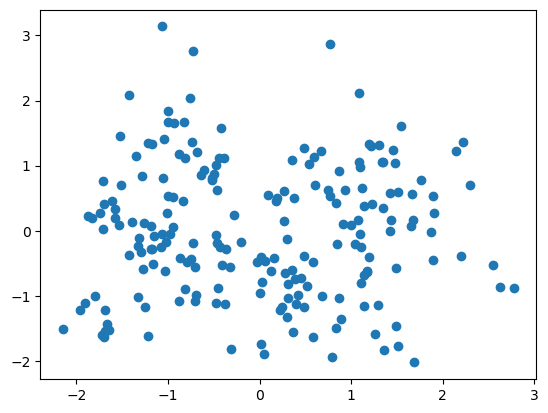

In [76]:
plt.figure()
col='Anuual income'
scatter=plt.scatter(X_pca[:,0],X_pca[:,1,c=df[col])
plt.scatter(X_pca[:,0],X_pca[:,1])
plt.xlabel("principle compoents 1")
plt.ylabel("principle compoent2")
plt.tilttle("pca customer ")